In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [4]:
data = pd.read_csv("/cryptonews.csv")

In [11]:
print("Dataset shape: ", data.shape)
print("List of columns: ", data.columns.tolist)
print("data types: \n", data.dtypes)

Dataset shape:  (31037, 7)
List of columns:  <bound method IndexOpsMixin.tolist of Index(['date', 'sentiment', 'source', 'subject', 'text', 'title', 'url'], dtype='object')>
data types: 
 date         object
sentiment    object
source       object
subject      object
text         object
title        object
url          object
dtype: object


In [14]:
print("count of missing values is : \n", data.isna().sum())
#Since it is a clean dataset, it is quite ideal for us to have the most ideal dataset, with close to zero null values.

count of missing values is : 
 date         0
sentiment    0
source       0
subject      0
text         0
title        0
url          0
dtype: int64


In [17]:
print(data["sentiment"].value_counts())

sentiment
{'class': 'neutral', 'polarity': 0.0, 'subjectivity': 0.0}        6916
{'class': 'positive', 'polarity': 0.5, 'subjectivity': 0.5}        655
{'class': 'positive', 'polarity': 0.14, 'subjectivity': 0.45}      498
{'class': 'neutral', 'polarity': 0.0, 'subjectivity': 1.0}         484
{'class': 'neutral', 'polarity': 0.0, 'subjectivity': 0.5}         380
                                                                  ... 
{'class': 'positive', 'polarity': 0.8, 'subjectivity': 0.7}          1
{'class': 'negative', 'polarity': -0.22, 'subjectivity': 0.67}       1
{'class': 'positive', 'polarity': 0.04, 'subjectivity': 0.75}        1
{'class': 'negative', 'polarity': -0.11, 'subjectivity': 0.64}       1
{'class': 'negative', 'polarity': -0.11, 'subjectivity': 0.63}       1
Name: count, Length: 3931, dtype: int64


<Axes: xlabel='sentiment'>

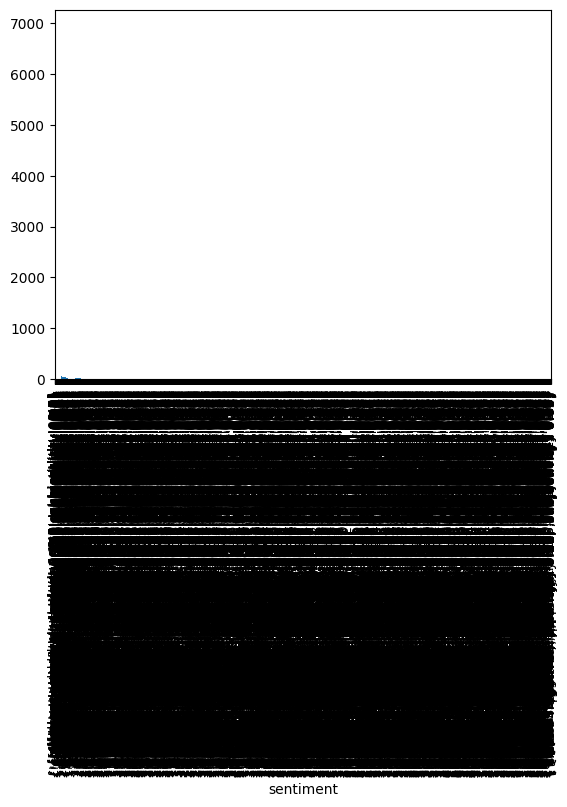

In [27]:
data["sentiment"].value_counts().plot(kind = "bar")

In [31]:
data['sentiment_dict'] = data['sentiment'].apply(ast.literal_eval)
data['sentiment_dict']

,sentiment_dict
0,"{'class': 'negative', 'polarity': -0.1, 'subje..."
1,"{'class': 'neutral', 'polarity': 0.0, 'subject..."
2,"{'class': 'positive', 'polarity': 0.05, 'subje..."
3,"{'class': 'positive', 'polarity': 0.5, 'subjec..."
4,"{'class': 'neutral', 'polarity': 0.0, 'subject..."
...,...
31032,"{'class': 'neutral', 'polarity': 0.0, 'subject..."
31033,"{'class': 'positive', 'polarity': 0.1, 'subjec..."
31034,"{'class': 'positive', 'polarity': 0.14, 'subje..."
31035,"{'class': 'neutral', 'polarity': 0.0, 'subject..."


In [32]:

data['sentiment_class'] = data['sentiment_dict'].apply(lambda d: d['class'])
data['polarity'] = data['sentiment_dict'].apply(lambda d: d['polarity'])
data['subjectivity'] = data['sentiment_dict'].apply(lambda d: d['subjectivity'])


,sentiment_class,polarity,subjectivity
0,negative,-0.10,0.60
1,neutral,0.00,0.00
2,positive,0.05,0.05
3,positive,0.50,0.90
4,neutral,0.00,0.00


<Axes: xlabel='sentiment_class'>

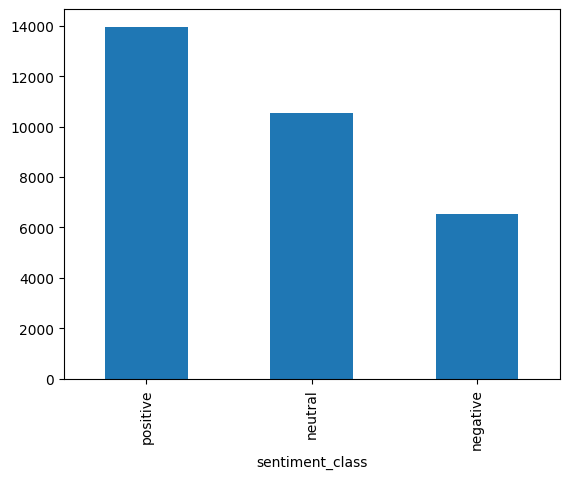

In [34]:
data['sentiment_class'].value_counts().plot(kind = "bar")

sentiment_class
negative    23.217245
neutral     19.578020
positive    23.799628
Name: word_count, dtype: float64


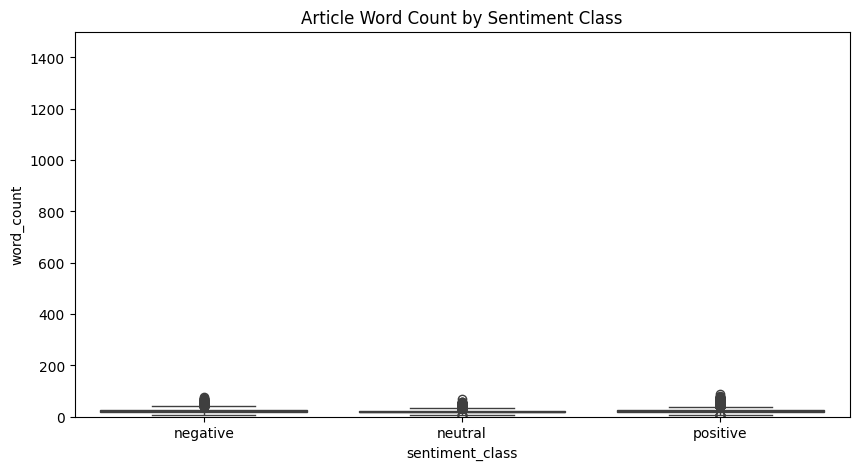

In [35]:
# 1. Calculate word count for each article
data['word_count'] = data['text'].apply(lambda x: len(str(x).split()))

# 2. Check basic stats across sentiment classes
print(data.groupby('sentiment_class')['word_count'].mean())

# 3. Visualize text length distribution by sentiment
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='sentiment_class', y='word_count')
plt.title('Article Word Count by Sentiment Class')
plt.ylim(0, 1500) # Zoom in to ignore extreme outliers
plt.show()

Text length stats:

count    31037.000000
mean       140.937494
std         47.741986
min         26.000000
25%        111.000000
50%        135.000000
75%        160.000000
max        513.000000
Name: text_length, dtype: float64


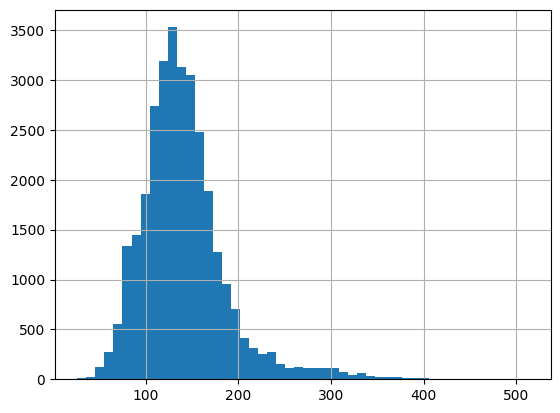

In [47]:
data['text_length'] = data['text'].str.len()
print("Text length stats:\n")
print(data['text_length'].describe())

data['text_length'].hist(bins=50)
plt.show()

In [48]:
print(data[['title', 'text_length', 'sentiment_class']].head(n = 10))

                                               title  text_length  \
0  Grayscale CEO Calls for Simultaneous Approval ...          125   
1  Indian Government is Actively Collaborating Wi...          207   
2  Judge Approves Settlement: Binance to Pay $1.5...          207   
3  Why a gold rush for inscriptions has broken ha...          176   
4  ‘Concerning precedent’ — bloXroute Labs' MEV r...          130   
5  Is This Why Bitcoin’s Price Rally Was Halted? ...          136   
6  Cathie Wood’s Ark Invest Sells $27.6 Million i...          121   
7  Bitcoin Soared 150% in 2023 But These Companie...          129   
8  South Korean City Busan Names Digital Exchange...          165   
9  SEC delays several Ethereum ETFs, pushing fina...          133   

  sentiment_class  
0        negative  
1         neutral  
2        positive  
3        positive  
4         neutral  
5        negative  
6        positive  
7         neutral  
8         neutral  
9        negative  
